In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Base directory
# ==========================================================

BASE = Path("/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/")

SOLID_DIR = BASE / "solid" / "v18_reissner_mindlin_plate"
SOLID_DIAG_DIR = SOLID_DIR / "diagnostics"

FLUID_DIR = BASE / "fluid" / "v9"

COUPLING_DIR = BASE / "coupling"

# ==========================================================
# Save figures (unchanged)
# ==========================================================

FIG_DIR = Path.cwd() / "plots" / "validation_span_corespreading"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Problem parameters
# ==========================================================

span = 0.30
chord = 0.10
Uinf = 0.30
kG = 1.82
nu = 1.0e-6

freq = kG * Uinf / (np.pi * chord)
omega = 2 * np.pi * freq
Tcycle = 1.0 / freq

print("Base      :", BASE)
print("Solid     :", SOLID_DIR)
print("Fluid     :", FLUID_DIR)
print("Coupling  :", COUPLING_DIR)
print("Figures   :", FIG_DIR)

Base      : /media/dysco/New Volume/Neeraj/varflexi solver/results/best_result_validation
Solid     : /media/dysco/New Volume/Neeraj/varflexi solver/results/best_result_validation/solid/v18_reissner_mindlin_plate
Fluid     : /media/dysco/New Volume/Neeraj/varflexi solver/results/best_result_validation/fluid/v9
Coupling  : /media/dysco/New Volume/Neeraj/varflexi solver/results/best_result_validation/coupling
Figures   : /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/FINAL/notebooks/plots/validation_span


In [2]:
def read_fluid_diagnostics(path: Path) -> pd.DataFrame:
    cols = [
        "step", "time", "nParticles", "lift", "drag", "moment",
        "forceNorm", "gammaMax", "gammaMean", "sigmaMax",
        "sigmaMean", "cpuTime",
    ]
    # file has a 5-line wrapped header
    return pd.read_csv(path, skiprows=5, header=None, names=cols)

def read_jsonl_spanwise_forces(path: Path, force_key: str):
    steps = []
    forces = []
    meta = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            steps.append(obj["step"])
            forces.append(np.asarray(obj[force_key], dtype=float))
            meta.append(obj)
    return np.asarray(steps), np.stack(forces), meta

In [3]:
# ==========================================================
# SOLID
# ==========================================================

solid = pd.read_csv(
    SOLID_DIAG_DIR / "solid_diagnostics.csv"
)


# ==========================================================
# FLUID
# ==========================================================

fluid_diag = read_fluid_diagnostics(
    FLUID_DIR / "fluid_v9_fluid_diagnostics.csv"
)


tip = pd.read_csv(
    FLUID_DIR / "tip_displacement.csv"
)

fluid_cp = pd.read_csv(
    FLUID_DIR / "fluid_v9_fluid_cp_le_te_coords.csv"
)

coupling_diag = pd.read_csv(
    FLUID_DIR / "fluid_v9_coupling_diagnostics.csv"
)

payload_steps, payload_force, payload_meta = read_jsonl_spanwise_forces(
    FLUID_DIR / "fluid_v9_force_payload_history.jsonl",
    "force",
)

# ==========================================================
# COUPLING
# ==========================================================

coupling_hist = pd.read_csv(
    COUPLING_DIR / "coupling_history.csv"
)

pair_steps, force_received, pair_meta = read_jsonl_spanwise_forces(
    COUPLING_DIR / "forces_sent_received_history.jsonl",
    "force_received",
)

_, force_sent, _ = read_jsonl_spanwise_forces(
    COUPLING_DIR / "forces_sent_received_history.jsonl",
    "force_sent",
)

# ==========================================================
# TARGET LOCATIONS
# ==========================================================

cp_targets = pd.read_csv(
    SOLID_DIR / "coupling_cp_targets.csv"
)

le_targets = pd.read_csv(
    SOLID_DIR / "coupling_le_targets.csv"
)

te_targets = pd.read_csv(
    SOLID_DIR / "coupling_te_targets.csv"
)

reference_file = Path.cwd() / "Fig4_tipdisp_time.csv"

ref = pd.read_csv(reference_file)

print(ref.columns)
display(ref.head())

Index(['-0.0029069767441862737', ' 1.484126984126986'], dtype='object')


,-0.0029069767441862737,1.484126984126986
0,0.069767,1.636508
1,0.139535,1.496825
2,0.209302,1.071429
3,0.281977,0.385714
4,0.351744,-0.312698


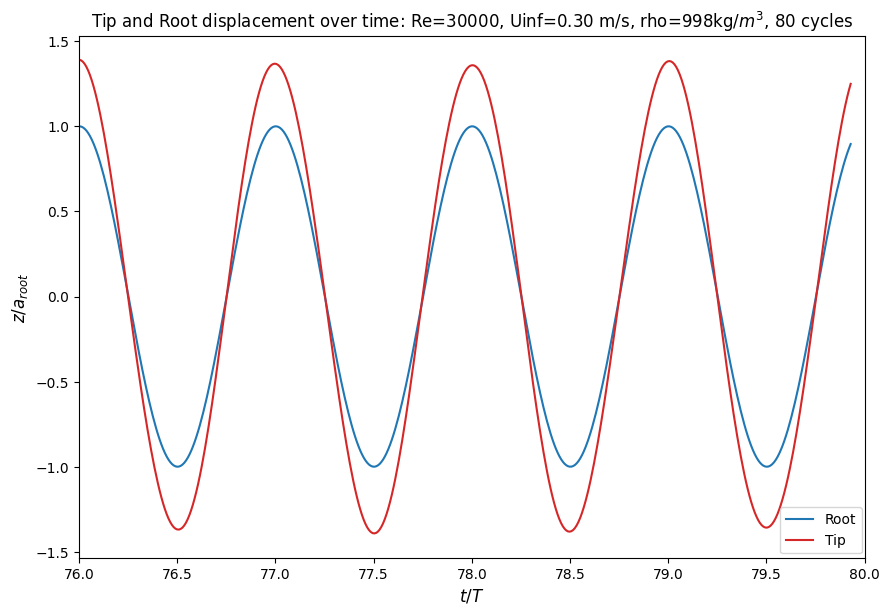

In [21]:
time = tip["time"].to_numpy()
root_z = tip["root_z"].to_numpy()
tip_z = tip["tip_z"].to_numpy()
time_nd = time / Tcycle
a_root = 0.175 * chord

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(time_nd, root_z / a_root, label="Root", color="tab:blue")
ax.plot(time_nd, tip_z / a_root, label="Tip", color="tab:red")
ax.set_xlabel(r"$t/T$", fontsize=12)
ax.set_ylabel(r"$z/a_{root}$", fontsize=12)
ax.grid(False)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.005, 0.11),
    frameon=True,
)

plt.xlim(76,80)
fig.tight_layout()
fig.savefig(FIG_DIR / "motion_root_tip_nd.pdf", bbox_inches="tight")
plt.title("Tip and Root displacement over time: Re=30000, Uinf=0.30 m/s, rho=998kg/$m^3$, 80 cycles")
plt.show()

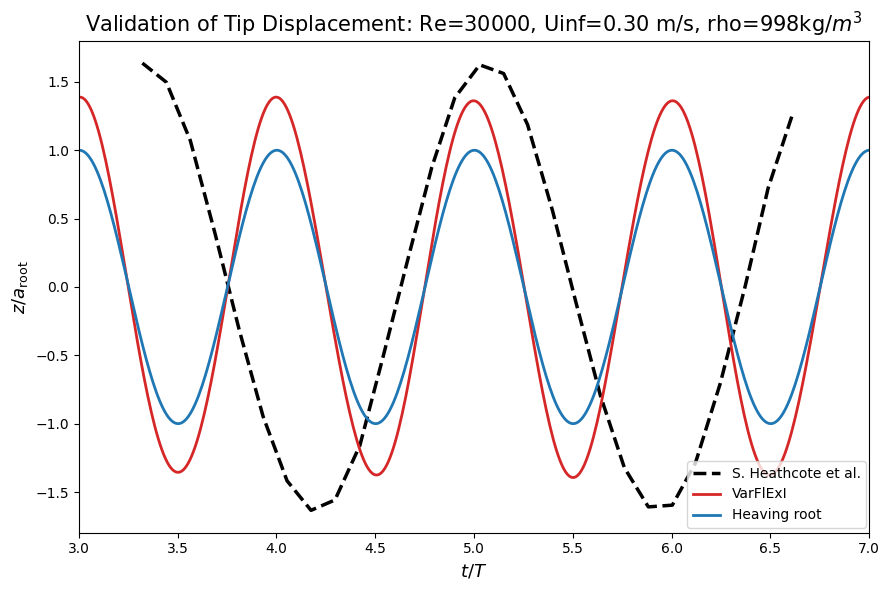

In [5]:
# ==========================================================
# Reference vs Present Solver (Non-dimensional)
# ==========================================================

# Reference data
t_ref = ref.iloc[:, 0].to_numpy()
tip_ref = ref.iloc[:, 1].to_numpy()

# Our solution
time = tip["time"].to_numpy()
root_z = tip["root_z"].to_numpy()
tip_z = tip["tip_z"].to_numpy()

# Non-dimensionalization
time_nd = time / Tcycle
time_ref_nd = t_ref / Tcycle        # <-- remove this line if reference time is already t/T

a_root = 0.175 * chord

fig, ax = plt.subplots(figsize=(9,6))

shift_cycles = 3.2

time_ref_shifted = time_ref_nd + shift_cycles

# Reference
ax.plot(
    time_ref_shifted,
    tip_ref,
    "k--",
    linewidth=2.5,
    label=f"S. Heathcote et al."
)

# to remove transients (t shifted by {shift_cycles:.1f}T)
# Present tip
ax.plot(
    time_nd,
    tip_z / a_root,
    linewidth=2,
    color="tab:red",
    label="VarFlExI"
)

# Present root
ax.plot(
    time_nd,
    root_z / a_root,
    linewidth=2,
    color="tab:blue",
    label="Heaving root"
)

ax.set_xlabel(r"$t/T$", fontsize=13)
ax.set_ylabel(r"$z/a_{\mathrm{root}}$", fontsize=13)
ax.set_title("Validation of Tip Displacement: Re=30000, Uinf=0.30 m/s, rho=998kg/$m^3$", fontsize=15)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.005, 0.16),
    frameon=True,
)

ax.set_xlim(3, 7)
ax.grid(False)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "tip_displacement_reference_comparison.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

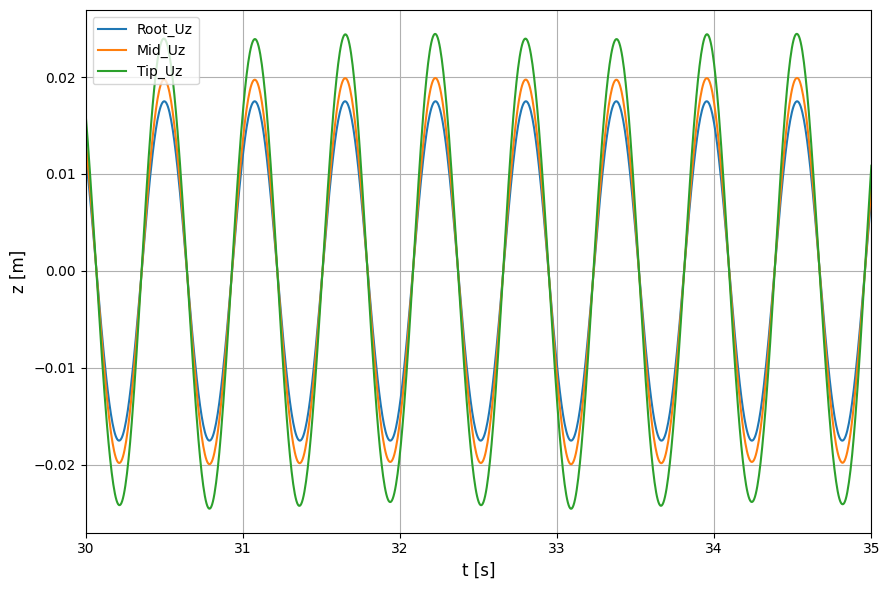

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(solid["Time"], solid["Root_Uz"], label="Root_Uz")
ax.plot(solid["Time"], solid["Mid_Uz"], label="Mid_Uz")
ax.plot(solid["Time"], solid["Tip_Uz"], label="Tip_Uz")
ax.set_xlabel("t [s]", fontsize=12)
ax.set_ylabel("z [m]", fontsize=12)
ax.grid(True)
ax.legend()
plt.xlim(30,35)
fig.tight_layout()
fig.savefig(FIG_DIR / "solid_displacements_root_mid_tip.pdf", bbox_inches="tight")
plt.show()

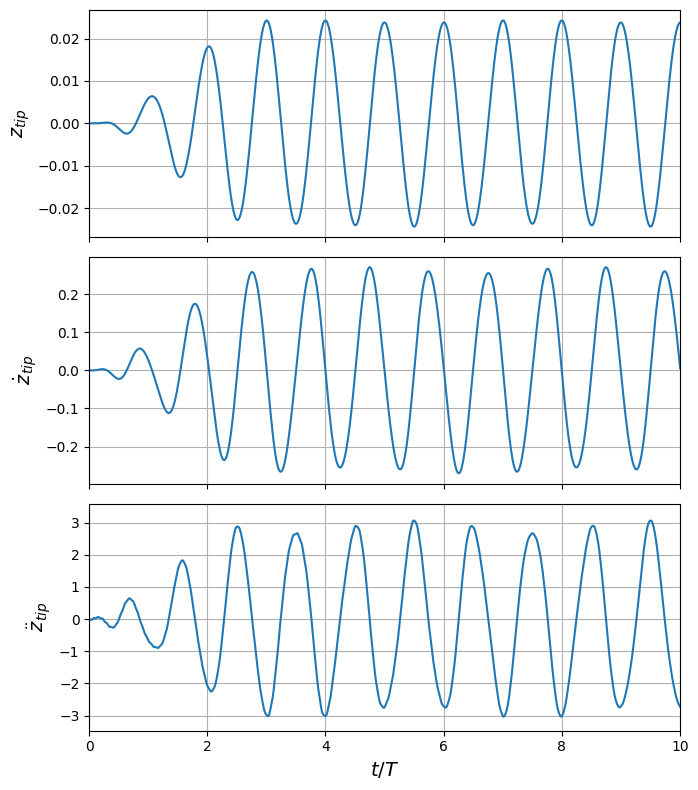

In [7]:
dt = np.mean(np.diff(time))
tip_v = np.gradient(tip_z, dt)
tip_a = np.gradient(tip_v, dt)

fig, axs = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
# plt.title("Tip motion kinematics: Re=30000, Uinf=0.30 m/s, rho=998kg/$m^3$")
axs[0].plot(time_nd, tip_z)
axs[0].set_ylabel(r"$z_{tip}$", fontsize=14)
axs[0].grid(True)
axs[1].plot(time_nd, tip_v)
axs[1].set_ylabel(r"$\dot z_{tip}$", fontsize=14)
axs[1].grid(True)
axs[2].plot(time_nd, tip_a)
axs[2].set_ylabel(r"$\ddot z_{tip}$", fontsize=14)
axs[2].set_xlabel(r"$t/T$", fontsize=14)
axs[2].grid(True)
fig.tight_layout()
plt.xlim(0,10)

fig.savefig(FIG_DIR / "tip_motion_kinematics.pdf", bbox_inches="tight")
plt.show()

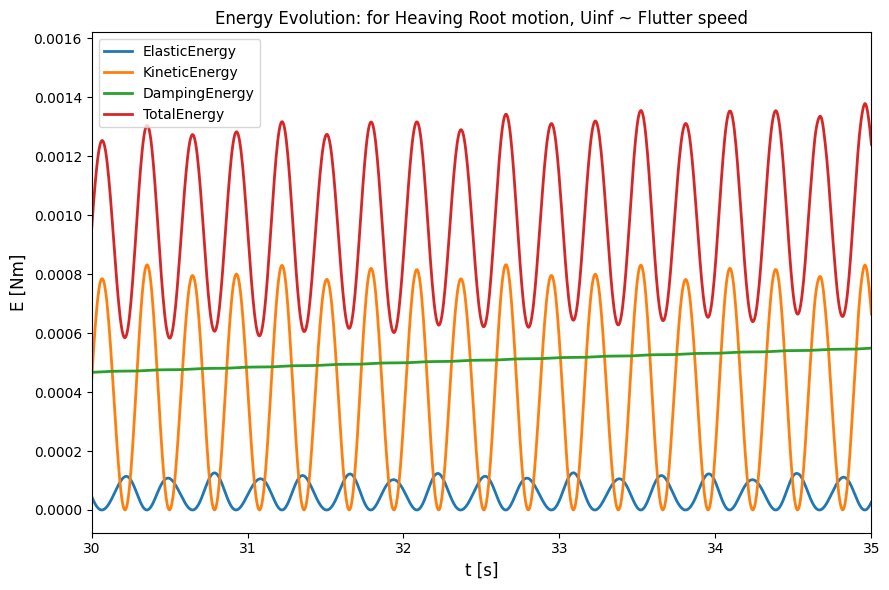

In [8]:
# ==========================================================
# Solid Energy History
# ==========================================================
t = solid["Time"].to_numpy()

fig, ax = plt.subplots(figsize=(9,6))

for c in ["ElasticEnergy", "KineticEnergy", "DampingEnergy", "TotalEnergy"]:
    ax.plot(t, solid[c], linewidth=2, label=c)

ax.set_xlabel("t [s]", fontsize=12)
ax.set_ylabel("E [Nm]", fontsize=12)
ax.set_title("Energy Evolution: for Heaving Root motion, Uinf ~ Flutter speed", fontsize=12)
ax.grid(False)
ax.legend()
plt.xlim(30,35)


fig.tight_layout()
fig.savefig(FIG_DIR / "solid_energy_history.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Uinf ~ flutter speed (above plot)

In [9]:
# # ==========================================================
# # Work Conservation
# # ==========================================================

# fig, ax = plt.subplots(figsize=(8,5))

# # Plot every Nth marker to avoid clutter
# markevery = max(1, len(t)//30)

# ax.plot(
#     t,
#     solid["CumFluidWork"],
#     color="tab:blue",
#     linestyle="-",
#     linewidth=3,
#     marker="o",
#     markersize=8,
#     markevery=markevery,
#     label="Cumulative $W_f$",
# )

# ax.plot(
#     t,
#     solid["CumStructuralWork"],
#     color="tab:orange",
#     linestyle="--",
#     linewidth=2,
#     marker="s",
#     markersize=5,
#     markevery=markevery,
#     label="Cumulative $W_s$",
# )

# ax.plot(
#     t,
#     np.abs(solid["WorkError"]),
#     color="tab:green",
#     linestyle="-.",
#     linewidth=3,
#     marker="^",
#     markersize=7,
#     markevery=markevery,
#     label="$|W_f - W_s|$",
# )

# ax.set_xlabel("t [s]", fontsize=12)
# ax.set_ylabel("W [Nm]", fontsize=12)
# ax.set_title("Work Conservation", fontsize=12)
# # plt.xlim(30,35)

# ax.grid(False)
# ax.legend(frameon=True)

# fig.tight_layout()
# fig.savefig(FIG_DIR / "solid_work_balance.pdf",
#             dpi=300,
#             bbox_inches="tight")

# plt.show()

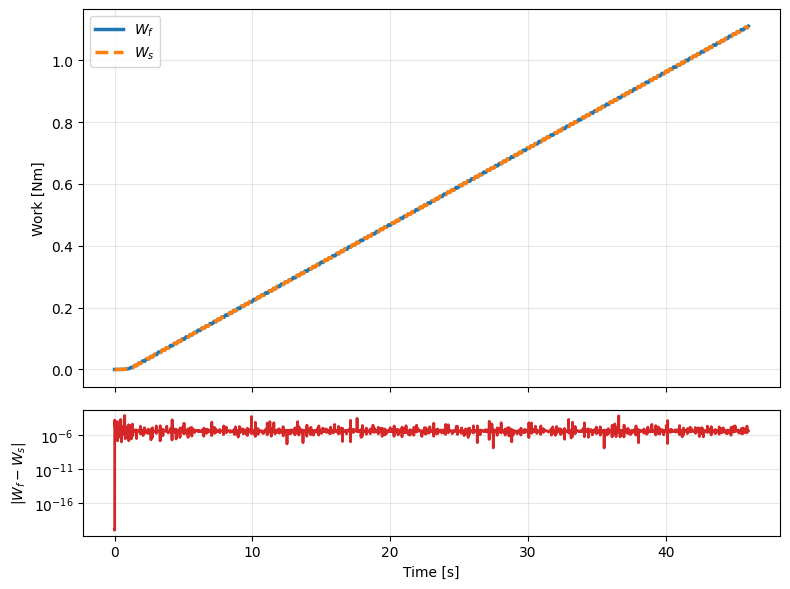

In [10]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8,6),
    sharex=True,
    gridspec_kw={"height_ratios":[3,1]}
)

ax1.plot(t, solid["CumFluidWork"], lw=2.5, label=r"$W_f$")
ax1.plot(t, solid["CumStructuralWork"], "--", lw=2.5, label=r"$W_s$")
ax1.set_ylabel("Work [Nm]")
ax1.legend()
ax1.grid(True, alpha=0.3)

error = np.abs(solid["WorkError"])

ax2.semilogy(t, error + 1e-20, lw=2, color="tab:red")
ax2.set_ylabel(r"$|W_f-W_s|$")
ax2.set_xlabel("Time [s]")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()


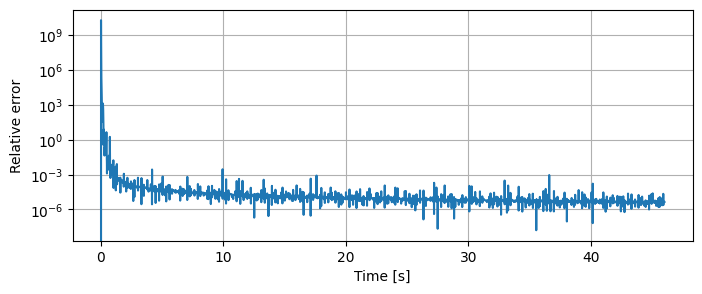

In [11]:
eps = 1e-15

rel_error = (
    np.abs(solid["WorkError"])
    /
    np.maximum.reduce([
        np.abs(solid["CumFluidWork"]),
        np.abs(solid["CumStructuralWork"]),
        np.full_like(t, eps)
    ])
)

plt.figure(figsize=(8,3))
plt.semilogy(t, rel_error)
plt.xlabel("Time [s]")
plt.ylabel("Relative error")
plt.grid(True, which="both")

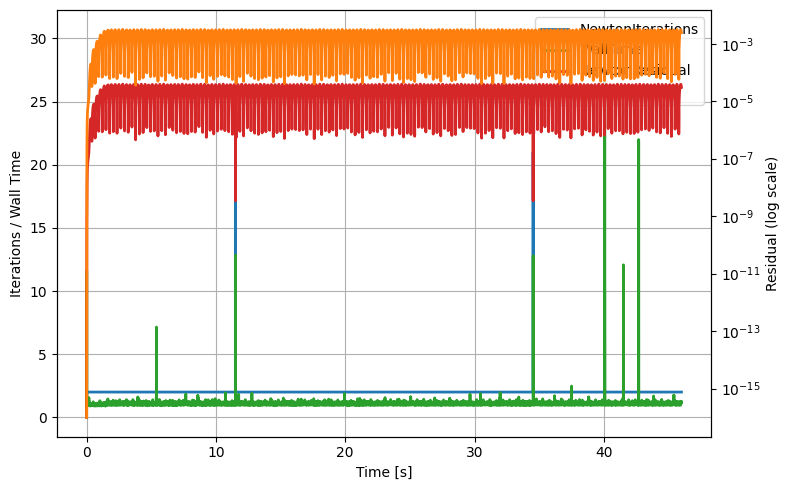

In [12]:
# ==========================================================
# Solver Diagnostics
# ==========================================================

fig, ax1 = plt.subplots(figsize=(8,5))

ax2 = ax1.twinx()

ax1.plot(
    t,
    solid["NewtonIterations"],
    linewidth=2,
    color="tab:blue",
    label="NewtonIterations"
)

ax1.plot(
    t,
    solid["WallTime"],
    linewidth=2,
    color="tab:green",
    label="WallTime"
)

ax2.semilogy(
    t,
    np.maximum(solid["NewtonResidual"],1e-16),
    linewidth=2,
    color="tab:red",
    label="NewtonResidual"
)

ax2.semilogy(
    t,
    np.maximum(solid["ForceNorm"],1e-16),
    linewidth=2,
    color="tab:orange",
    label="ForceNorm"
)

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Iterations / Wall Time")
ax2.set_ylabel("Residual (log scale)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.grid(True)

fig.tight_layout()
fig.savefig(FIG_DIR / "solid_solver_diagnostics.pdf", dpi=300, bbox_inches="tight")
plt.show()

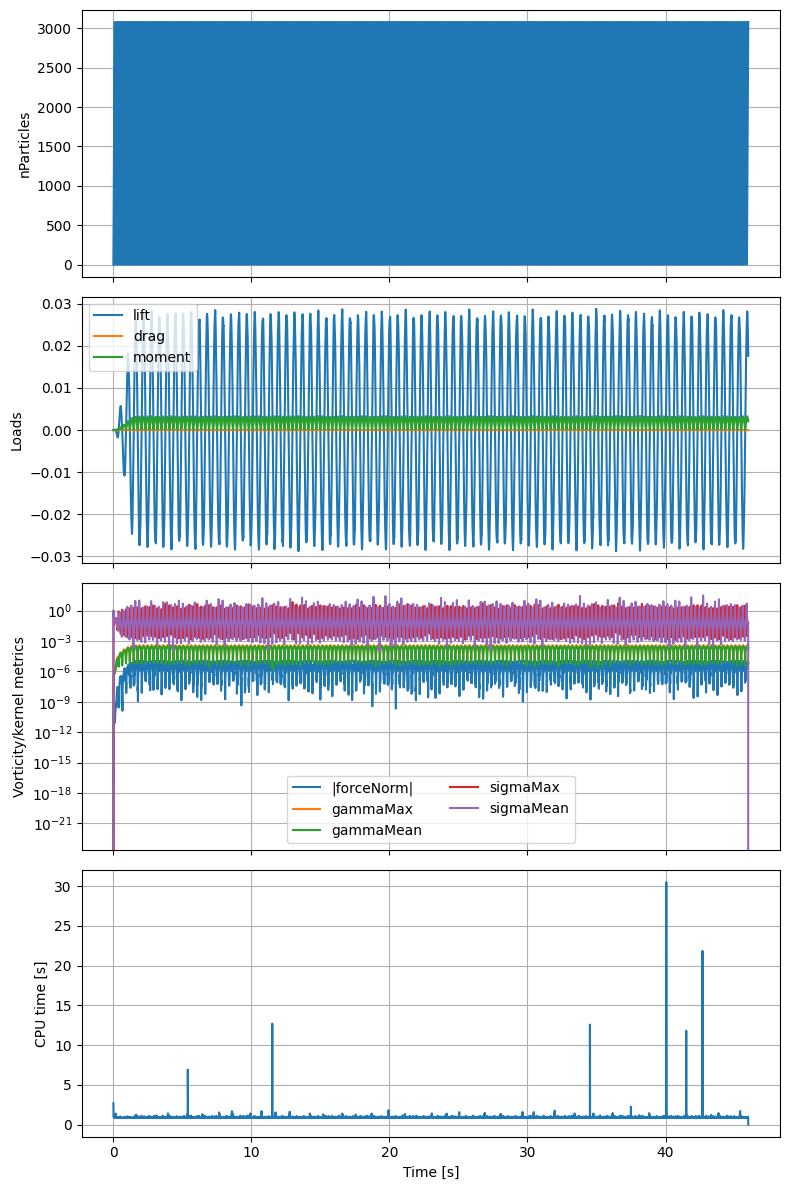

In [13]:
tf = fluid_diag["time"].to_numpy()

fig, axs = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

axs[0].plot(tf, fluid_diag["nParticles"])
axs[0].set_ylabel("nParticles")
axs[0].grid(True)

axs[1].plot(tf, fluid_diag["lift"], label="lift")
axs[1].plot(tf, fluid_diag["drag"], label="drag")
axs[1].plot(tf, fluid_diag["moment"], label="moment")
axs[1].set_ylabel("Loads")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(tf, np.abs(fluid_diag["forceNorm"]), label="|forceNorm|")
axs[2].plot(tf, fluid_diag["gammaMax"], label="gammaMax")
axs[2].plot(tf, fluid_diag["gammaMean"], label="gammaMean")
axs[2].plot(tf, fluid_diag["sigmaMax"], label="sigmaMax")
axs[2].plot(tf, fluid_diag["sigmaMean"], label="sigmaMean")
axs[2].set_yscale("log")
axs[2].set_ylabel("Vorticity/kernel metrics")
axs[2].grid(True, which="both")
axs[2].legend(ncol=2)

axs[3].plot(tf, fluid_diag["cpuTime"])
axs[3].set_xlabel("Time [s]")
axs[3].set_ylabel("CPU time [s]")
axs[3].grid(True)

fig.tight_layout()
fig.savefig(FIG_DIR / "fluid_diagnostics_all.pdf", bbox_inches="tight")
plt.show()

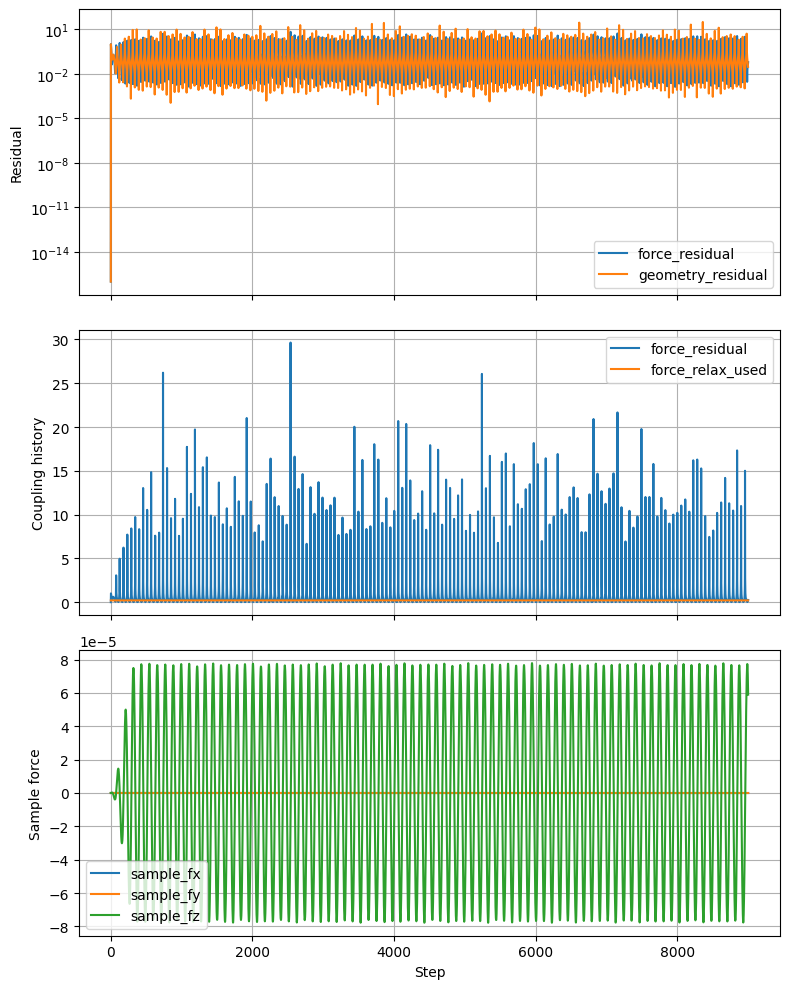

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axs[0].semilogy(
    coupling_diag["step"],
    np.maximum(coupling_diag["force_residual"], 1e-16),
    label="force_residual",
)
axs[0].semilogy(
    coupling_diag["step"],
    np.maximum(coupling_diag["geometry_residual"], 1e-16),
    label="geometry_residual",
)
axs[0].set_ylabel("Residual")
axs[0].grid(True, which="both")
axs[0].legend()

axs[1].plot(coupling_hist["step"], coupling_hist["force_residual"], label="force_residual")
axs[1].plot(coupling_hist["step"], coupling_hist["force_relax_used"], label="force_relax_used")
axs[1].set_ylabel("Coupling history")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(coupling_hist["step"], coupling_hist["sample_fx"], label="sample_fx")
axs[2].plot(coupling_hist["step"], coupling_hist["sample_fy"], label="sample_fy")
axs[2].plot(coupling_hist["step"], coupling_hist["sample_fz"], label="sample_fz")
axs[2].set_xlabel("Step")
axs[2].set_ylabel("Sample force")
axs[2].grid(True)
axs[2].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "coupling_diagnostics_all.pdf", bbox_inches="tight")
plt.show()

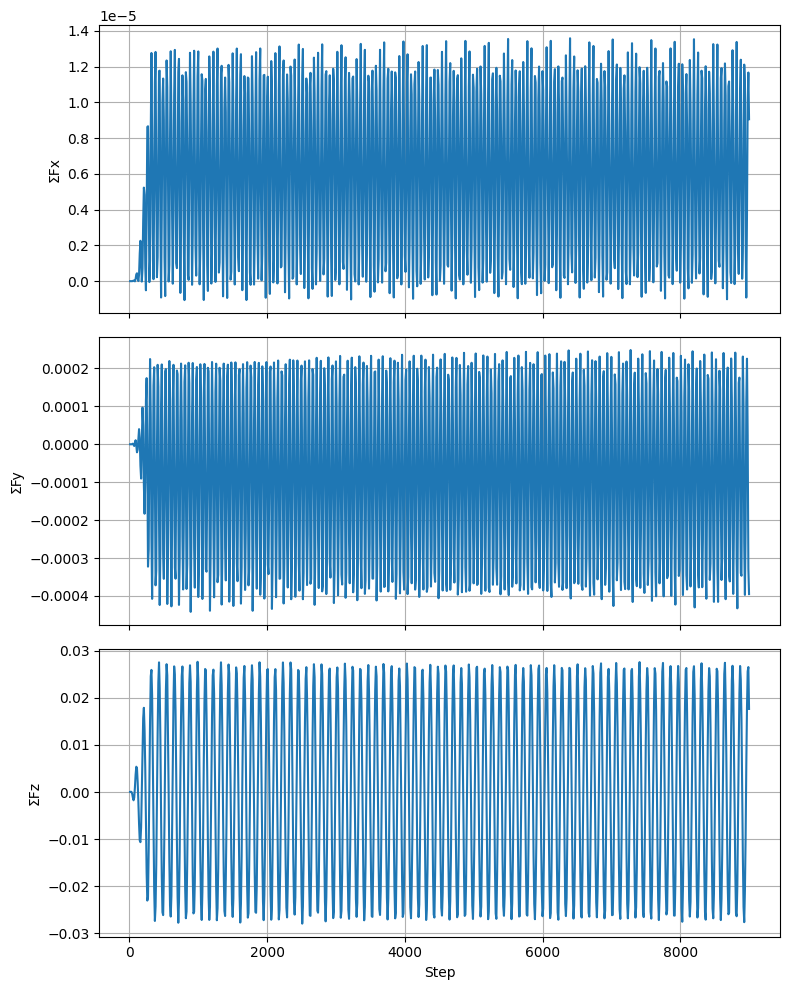

In [15]:
# fluid_v9_force_payload_history.jsonl: force only, every 10th step
payload_total = payload_force.sum(axis=1)  # (snapshots, 3)
payload_span = np.arange(1, payload_force.shape[1] + 1)

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
for i, comp in enumerate(["x", "y", "z"]):
    axs[i].plot(payload_steps, payload_total[:, i])
    axs[i].set_ylabel(f"ΣF{comp}")
    axs[i].grid(True)
axs[2].set_xlabel("Step")
fig.tight_layout()
fig.savefig(FIG_DIR / "force_payload_totals_vs_step.pdf", bbox_inches="tight")
plt.show()

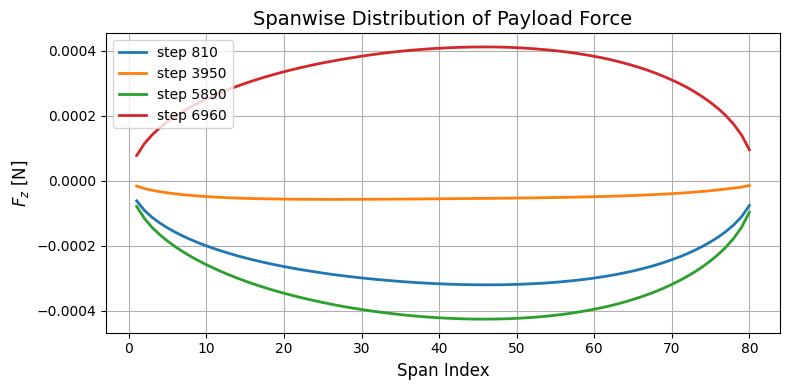

In [16]:
# ==========================================================
# Spanwise Fz profile at three random time steps
# ==========================================================

rng = np.random.default_rng(seed=42)   # Change seed for different random choices

sel = np.sort(
    rng.choice(len(payload_steps), size=4, replace=False)
)

fig, ax = plt.subplots(figsize=(8, 4))

for idx in sel:
    ax.plot(
        payload_span,
        payload_force[idx, :, 2],
        linewidth=2,
        label=f"step {payload_steps[idx]}"
    )

ax.set_xlabel("Span Index", fontsize=12)
ax.set_ylabel(r"$F_z$ [N]", fontsize=12)
ax.set_title("Spanwise Distribution of Payload Force", fontsize=14)
ax.grid(True)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIG_DIR / "force_payload_spanwise_fz_random.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

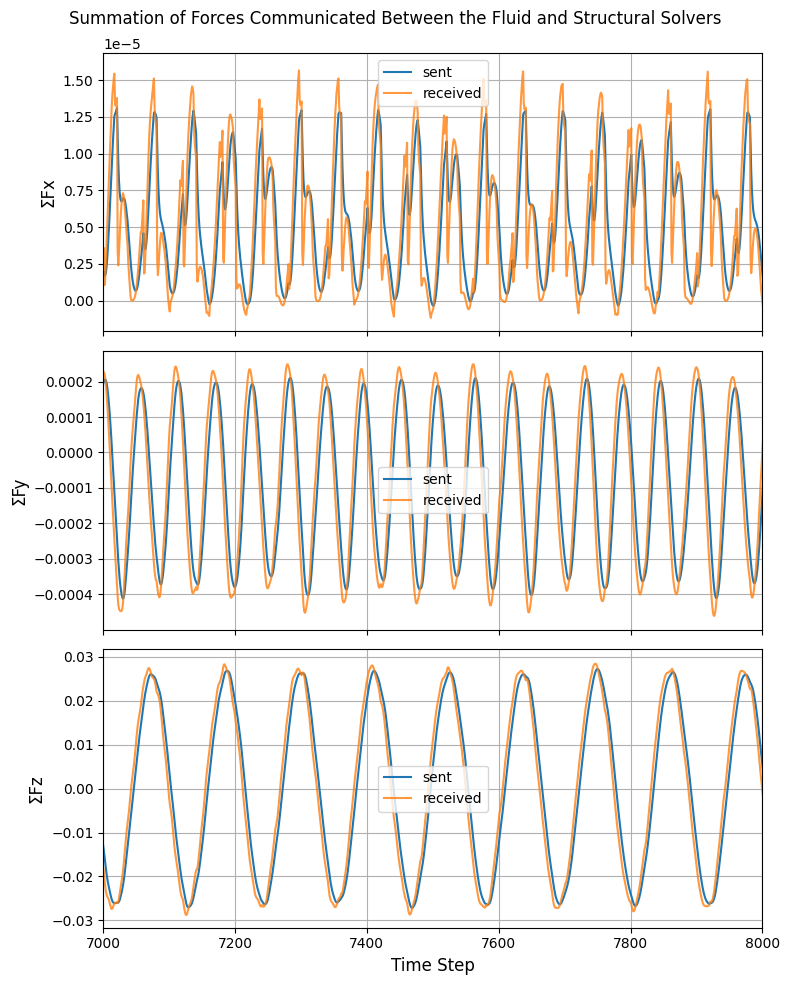

In [17]:
# forces_sent_received_history.jsonl: both sent and received, every step
pair_total_sent = force_sent.sum(axis=1)
pair_total_recv = force_received.sum(axis=1)
pair_span = np.arange(1, force_sent.shape[1] + 1)

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
for i, comp in enumerate(["x", "y", "z"]):
    axs[i].plot(pair_steps, pair_total_sent[:, i], label="sent")
    axs[i].plot(pair_steps, pair_total_recv[:, i], label="received", alpha=0.8)
    axs[i].set_ylabel(f"ΣF{comp}", fontsize=12)
    axs[i].grid(True)
    axs[i].legend()
axs[2].set_xlabel("Time Step", fontsize=12)
plt.xlim(7000,8000)
fig.suptitle(
    "Summation of Forces Communicated Between the Fluid and Structural Solvers",
    fontsize=12,
    y=0.98,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "force_sent_received_totals.pdf", bbox_inches="tight")
plt.show()

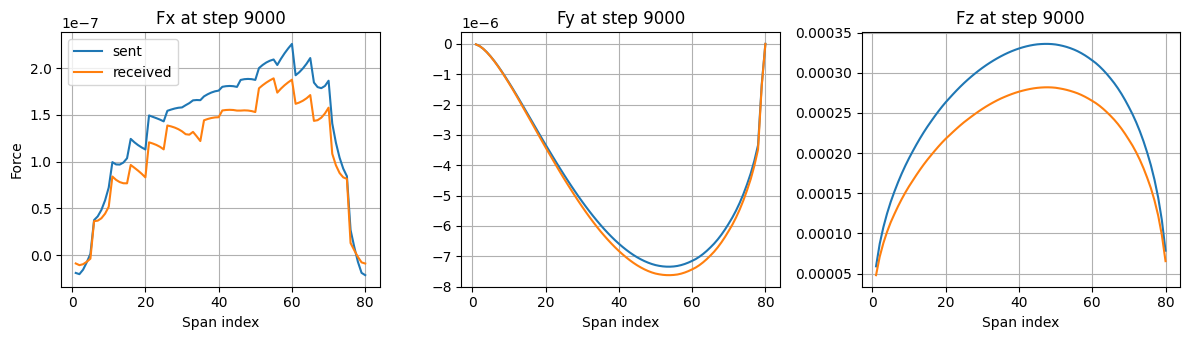

In [18]:
# One-step spanwise comparison
idx = -1
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
for j, comp in enumerate(["x", "y", "z"]):
    axs[j].plot(pair_span, force_sent[idx, :, j], label="sent")
    axs[j].plot(pair_span, force_received[idx, :, j], label="received")
    axs[j].set_title(f"F{comp} at step {pair_steps[idx]}")
    axs[j].set_xlabel("Span index")
    axs[j].grid(True)
axs[0].set_ylabel("Force")
axs[0].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "force_raw_relaxed_spanwise_laststep.pdf", bbox_inches="tight")
plt.show()

In [19]:
# # Heatmap of sent Fz over time and span
# fig, ax = plt.subplots(figsize=(8, 8))
# im = ax.imshow(
#     force_sent[:, :, 2].T,
#     aspect="auto",
#     origin="lower",
#     extent=[pair_steps[0], pair_steps[-1], 1, pair_span[-1]],
# )
# ax.set_xlabel("Step")
# ax.set_ylabel("Span index")
# ax.set_title("Sent Fz heatmap")
# fig.colorbar(im, ax=ax, label="Fz")
# fig.tight_layout()
# fig.savefig(FIG_DIR / "force_sent_fz_heatmap.pdf", bbox_inches="tight")
# plt.show()

In [20]:
# max_stress = []

# for f in stress_files:

#     mesh = pv.read(f)

#     if STRESS_FIELD in mesh.point_data:

#         stress = mesh.point_data[STRESS_FIELD]

#     elif STRESS_FIELD in mesh.cell_data:

#         stress = mesh.cell_data[STRESS_FIELD]

#     else:
#         raise RuntimeError(
#             f"Stress field '{STRESS_FIELD}' not found."
#         )

#     stress = np.asarray(stress)

#     max_stress.append(
#         np.max(np.abs(stress))
#     )

# max_stress = np.array(max_stress)

# print("Extracted stress history.")